# Optimal Interpolation on Lorenz-63 — analysis + free forecast

The closed-form linear-Gaussian baseline. Given prior
$\mathcal{N}(x_b, B)$ and obs $y \mid x \sim \mathcal{N}(Hx, R)$,
the posterior mean is

$$
x^* = x_b + K (y - H x_b), \qquad K = B H^\top (H B H^\top + R)^{-1}.
$$

OI does **per-time-step** analysis with no dynamics constraint. We
run it on the 0.5-time-unit assim window, then take the last
analysed state and free-forecast for 9.5 more time units. Without a
dynamics-aware analysis the forecast diverges from the truth almost
immediately — this is the canonical baseline that 4DVar then beats.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import (
    Lorenz63Forward,
    assemble_full_trajectory,
    assim_batch,
    generate_problem,
    run_method,
)

## 1. Shared problem

Defaults: 0.5-time-unit assim window inside a 10-time-unit total
run (~9 Lyapunov times). Full state observed every 0.05 time
units, Gaussian noise std 0.5.

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = assim_batch(prob)
fwd = Lorenz63Forward(dt=prob.dt)
t_axis = jnp.arange(prob.T_total_plus_1) * prob.dt
print(f"T_assim={prob.T_assim} ({prob.T_assim * prob.dt} time units)")
print(f"T_total={prob.T_total} ({prob.T_total * prob.dt} time units)")
print(f"obs density inside assim window: {int(prob.mask.sum())} / {prob.mask.size}")

T_assim=50 (0.5 time units)
T_total=1000 (10.0 time units)
obs density inside assim window: 33 / 153


## 2. Build OI + run analysis + free-forecast

In [3]:
H = lx.IdentityLinearOperator(jax.ShapeDtypeStruct(prob.prior_mean.shape, jnp.float32))
oi = vdx.OptimalInterpolation(
    obs_op=vdx.LinearObs(H_mat=H),
    prior_mean=prob.prior_mean,
    prior_cov_op=prob.B_op,
    obs_cov_op=prob.R_op,
)


def oi_run():
    analysis = oi(batch)[0]  # (T_assim+1, 3)
    return assemble_full_trajectory(analysis, prob, fwd)


result = run_method("oi", oi_run, prob)
print(f"OI rmse_assim    = {result.rmse_assim:.3f}")
print(f"OI rmse_forecast = {result.rmse_forecast:.3f}")
print(f"OI rmse_total    = {result.rmse_total:.3f}")
print(f"OI runtime       = {result.runtime_ms:.1f} ms")

OI rmse_assim    = 15.110
OI rmse_forecast = 1.094
OI rmse_total    = 3.573
OI runtime       = 496.0 ms


## 3. Trajectories — truth, analysis, and free forecast

Three rows: x, y, z components. The assim window is highlighted in
yellow; everything to the right is the free forecast.

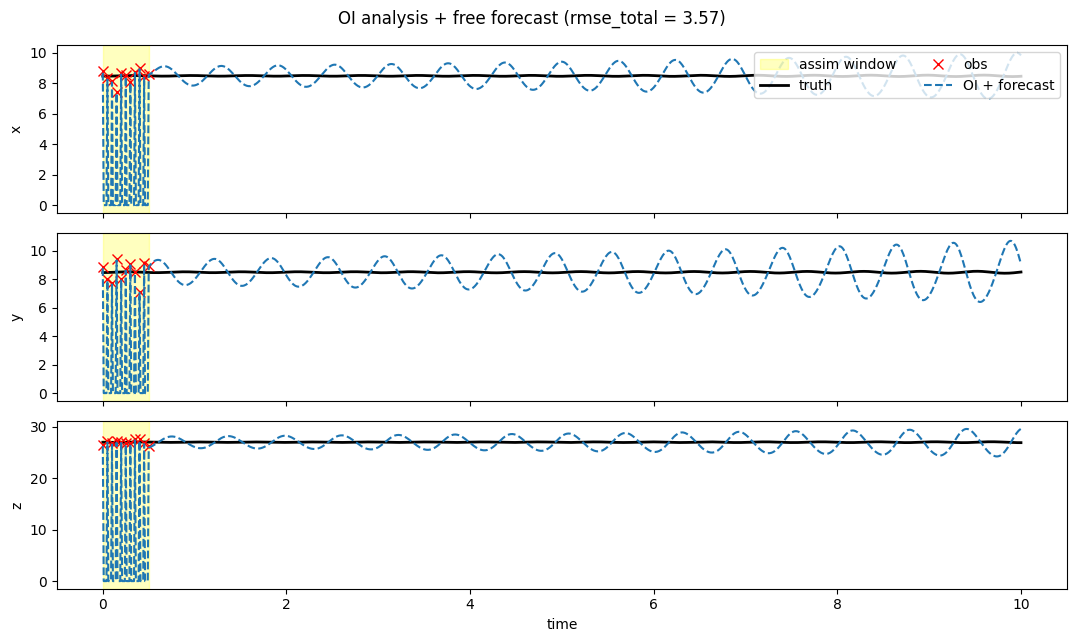

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(11, 6.5), sharex=True)
t_obs = t_axis[: prob.T_assim_plus_1][prob.mask[:, 0] > 0.5]
for i, ax in enumerate(axs):
    ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25,
               label="assim window")
    ax.plot(t_axis, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_v = prob.obs[prob.mask[:, i] > 0.5, i]
    if len(obs_v) > 0:
        ax.plot(t_obs, obs_v, "rx", ms=7, label="obs")
    ax.plot(t_axis, result.mean[:, i], "C0--", lw=1.5, label="OI + forecast")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right", ncol=2)
axs[-1].set_xlabel("time")
fig.suptitle(f"OI analysis + free forecast (rmse_total = {result.rmse_total:.2f})")
fig.tight_layout()
plt.show()

## 4. RMSE(t) — how fast does the forecast lose skill?

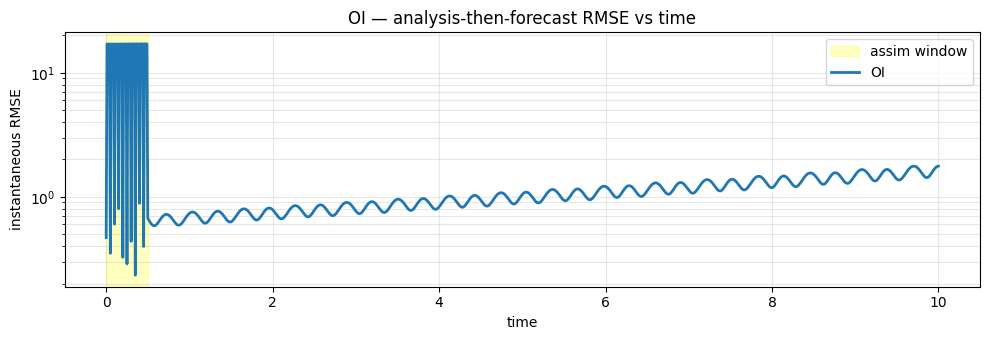

In [5]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axvspan(0.0, prob.T_assim * prob.dt, color="yellow", alpha=0.25,
           label="assim window")
ax.plot(t_axis, result.rmse_trace, "C0-", lw=2, label="OI")
ax.set_xlabel("time")
ax.set_ylabel("instantaneous RMSE")
ax.set_yscale("log")
ax.set_title("OI — analysis-then-forecast RMSE vs time")
ax.grid(True, alpha=0.3, which="both")
ax.legend()
fig.tight_layout()
plt.show()

## 5. Phase-space (butterfly) plot

Truth vs OI's analysis-plus-forecast in (x, z). Truth traces the
canonical Lorenz butterfly; the OI forecast quickly leaves the
attractor because its $x_0$ estimate is poor.

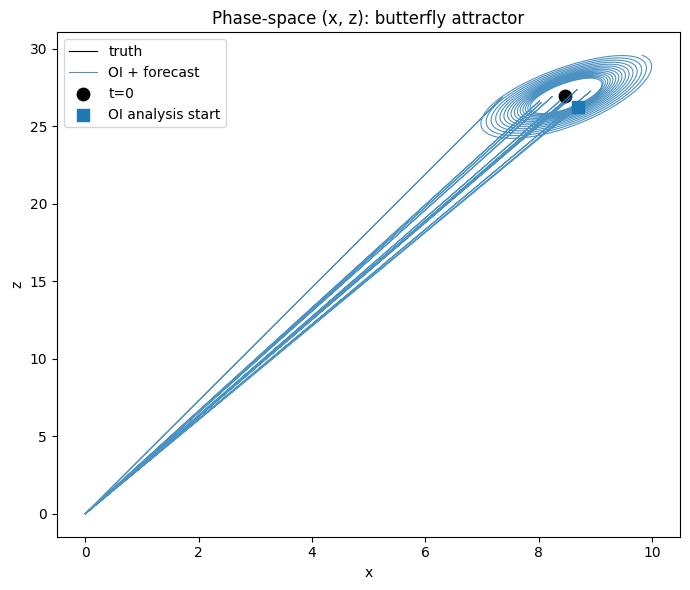

In [6]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(prob.truth[:, 0], prob.truth[:, 2], "k-", lw=0.8, label="truth")
ax.plot(result.mean[:, 0], result.mean[:, 2], "C0-", lw=0.8, alpha=0.8,
        label="OI + forecast")
ax.scatter(prob.truth[0, 0], prob.truth[0, 2], color="k", s=80, marker="o",
           label="t=0")
ax.scatter(result.mean[0, 0], result.mean[0, 2], color="C0", s=80, marker="s",
           label="OI analysis start")
ax.set_xlabel("x")
ax.set_ylabel("z")
ax.set_title("Phase-space (x, z): butterfly attractor")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

## 6. Discussion

OI's analysis fits the obs in the assim window (low rmse_assim),
but its analysis at $t = T_\text{assim}$ is just a noisy estimate
of the observed state — there's no mechanism to extract a smooth
$x_0$ for forecasting. The free forecast launched from that noisy
state diverges quickly: by the end of the 10-time-unit window the
RMSE has saturated at the attractor's intrinsic scale.

The next notebooks compare against 3DVar (which matches OI in the
linear-Gaussian limit — Decision D14) and then the dynamics-aware
methods that recover $x_0$ tightly enough to forecast for many
Lyapunov times. See [`08_benchmark_comparison`](08_benchmark_comparison.ipynb)
for all seven methods overlaid.